# Vietnamese Food Classifier
## Kiến trúc model

**Backbone: EfficientNet-B0** (pretrained ImageNet, qua thư viện `timm`)
- 5.3M parameters, ~80MB sau khi save
- Input: ảnh RGB 224x224, normalized theo ImageNet mean/std
- Output: vector logits 30 chiều (số class)

**Head:** thay layer classifier cuối của EfficientNet bằng `nn.Linear(1280 -> 30)` — `timm.create_model(num_classes=30)` xử lý tự động.

## Lý do chọn EfficientNet-B0

- **Cân bằng giữa accuracy và size**: B0 đạt ~77% top-1 trên ImageNet với chỉ 5M params, gấp 5 lần nhỏ hơn ResNet50 nhưng accuracy tương đương.
- **Phù hợp cho deploy**: 80MB model size → load nhanh trên Flask CPU server, inference ~50-100ms/ảnh không cần GPU.
- **Pretrained weights chất lượng cao** trên ImageNet-1K, transfer tốt cho food domain (ImageNet đã có nhiều class món ăn).
- **Compound scaling** của EfficientNet (đồng thời scale depth/width/resolution) tạo ra feature representations giàu hơn so với scale đơn lẻ.

## Pipeline training

1. EfficientNet-B0 pretrained ImageNet
2. Replace classifier head → 30 classes
3. Fine-tune toàn bộ network với AdamW + Cosine LR
4. Label smoothing 0.1 để chống overfit
5. Mixed precision (fp16) để tăng tốc trên T4
6. Early stopping theo val_acc

## Output sau training

- `best_model.pt` — checkpoint tốt nhất theo val accuracy
- `class_names.json` — danh sách 30 class
- `history.json` — loss/acc qua từng epoch
- `test_metrics.json` — accuracy, F1, precision, recall
- Các biểu đồ PNG: training curves, confusion matrix, metrics bar


## 1. Cài đặt môi trường

In [ ]:
# Chỉ cài timm + sklearn + seaborn — KHÔNG đụng numpy/torch của Colab
!pip install --no-cache-dir -q timm scikit-learn seaborn

print("Done")

Done


In [ ]:
!nvidia-smi || echo "Không có GPU - chuyển Runtime sang T4 GPU trước khi train"

Tue Apr 28 09:37:20 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   59C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 2. Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

DRIVE_BASE = '/content/drive/MyDrive/food_classifier'
os.makedirs(DRIVE_BASE, exist_ok=True)

PATHS = {
    'project': DRIVE_BASE,
    'images':  '/content/vqa_dataset_final',
    'splits':  f'{DRIVE_BASE}/splits',
    'best':    f'{DRIVE_BASE}/best_model.pt',
    'outputs': f'{DRIVE_BASE}/outputs',
    'recipes': '/content/drive/MyDrive/recipes.json',
    'export':  f'{DRIVE_BASE}/export',
}
for k, p in PATHS.items():
    if os.path.splitext(p)[1] == '':
        os.makedirs(p, exist_ok=True)

print("Paths configured:")
for k, v in PATHS.items():
    exists = 'OK' if os.path.exists(v) else 'MISSING'
    print(f"  {k:8s} -> {v}  [{exists}]")

Paths configured:
  project  -> /content/drive/MyDrive/food_classifier  [OK]
  images   -> /content/vqa_dataset_final  [OK]
  splits   -> /content/drive/MyDrive/food_classifier/splits  [OK]
  best     -> /content/drive/MyDrive/food_classifier/best_model.pt  [MISSING]
  outputs  -> /content/drive/MyDrive/food_classifier/outputs  [OK]
  recipes  -> /content/drive/MyDrive/recipes.json  [OK]
  export   -> /content/drive/MyDrive/food_classifier/export  [OK]


## 3. Giải nén dataset từ Drive

Dataset zip phải có sẵn ở `/content/drive/MyDrive/vqa_dataset_final.zip` với cấu trúc:
```
vqa_dataset_final/
  Pho/
    *.jpg
  Bun rieu/
    *.jpg
  ...
```

In [ ]:
import os, zipfile, glob

ZIP_PATH = '/content/drive/MyDrive/vqa_dataset_final.zip'

if os.path.exists(PATHS['images']) and len(os.listdir(PATHS['images'])) > 0:
    imgs = glob.glob(f"{PATHS['images']}/**/*.jpg", recursive=True)
    print(f"Dataset đã giải nén: {len(imgs)} ảnh")
elif os.path.exists(ZIP_PATH):
    print(f"Đang giải nén {ZIP_PATH} ...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        zf.extractall('/content/')
    imgs = glob.glob('/content/vqa_dataset_final/**/*.jpg', recursive=True)
    print(f"Giải nén xong: {len(imgs)} ảnh")
else:
    raise FileNotFoundError(f"Không tìm thấy {ZIP_PATH} — hãy upload zip lên Drive trước")

Đang giải nén /content/drive/MyDrive/vqa_dataset_final.zip ...
Giải nén xong: 3000 ảnh


## 4. Load recipes.json

In [ ]:
import json

with open(PATHS['recipes'], 'r', encoding='utf-8') as f:
    RECIPES = json.load(f)

CLASS_NAMES = sorted(RECIPES.keys())
NUM_CLASSES = len(CLASS_NAMES)
CLS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}
IDX_TO_CLS = {i: c for i, c in enumerate(CLASS_NAMES)}

print(f"Loaded {NUM_CLASSES} classes")
print(f"Sample: Pho -> {RECIPES['Pho']['name']}, {RECIPES['Pho']['nutrition']['calories']} kcal")

Loaded 30 classes
Sample: Pho -> Phở, 418 kcal


## 5. Code core (dataset + model)

In [ ]:
import os, glob, random
from PIL import Image
import torch
from torch.utils.data import Dataset
import torchvision.transforms as T


IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]


def get_transforms(img_size=224, train=False):
    """Train: augmentation. Val/test: chỉ resize + normalize."""
    if train:
        return T.Compose([
            T.Resize((img_size + 32, img_size + 32)),
            T.RandomCrop(img_size),
            T.RandomHorizontalFlip(p=0.5),
            T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
            T.ToTensor(),
            T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ])
    return T.Compose([
        T.Resize((img_size, img_size)),
        T.ToTensor(),
        T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])


def discover_images(images_root, class_names):
    """Quét folder dataset, trả list (image_path, class_name)."""
    pairs = []
    for cls in class_names:
        folder = os.path.join(images_root, cls)
        if not os.path.isdir(folder):
            continue
        for fn in sorted(os.listdir(folder)):
            if fn.lower().endswith(('.jpg', '.jpeg', '.png', '.webp')):
                pairs.append((os.path.join(folder, fn), cls))
    return pairs


def stratified_split(pairs, val_frac=0.1, test_frac=0.1, seed=42):
    """Split đều theo class — đảm bảo tập nào cũng có đủ class."""
    random.seed(seed)
    by_class = {}
    for p, c in pairs:
        by_class.setdefault(c, []).append((p, c))
    train, val, test = [], [], []
    for cls, items in by_class.items():
        random.shuffle(items)
        n = len(items)
        n_test = max(1, int(round(n * test_frac)))
        n_val  = max(1, int(round(n * val_frac)))
        test  += items[:n_test]
        val   += items[n_test:n_test + n_val]
        train += items[n_test + n_val:]
    random.shuffle(train); random.shuffle(val); random.shuffle(test)
    return {'train': train, 'val': val, 'test': test}


class FoodDataset(Dataset):
    def __init__(self, pairs, cls_to_idx, img_size=224, train=False):
        self.pairs = pairs
        self.cls_to_idx = cls_to_idx
        self.transform = get_transforms(img_size, train=train)

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        path, cls = self.pairs[idx]
        img = Image.open(path).convert('RGB')
        return self.transform(img), self.cls_to_idx[cls], path


In [ ]:
import torch.nn as nn
import timm


def build_model(num_classes, model_name='efficientnet_b0', pretrained=True):
    """
    EfficientNet-B0 từ timm với classifier head 30 classes.
    timm tự động thay layer cuối khi pass num_classes.
    """
    return timm.create_model(model_name, pretrained=pretrained, num_classes=num_classes)


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


## 6. Cấu hình + Train

Hyperparameters:
- Batch 32, AdamW lr=3e-4, weight_decay=1e-4
- Cosine annealing LR schedule
- Label smoothing 0.1 (giảm overconfidence, chống overfit)
- Mixed precision fp16 (T4 GPU)
- Early stopping theo val_acc, patience 4

In [ ]:
CFG = {
    'model_name':      'efficientnet_b0',
    'img_size':        224,
    'batch_size':      32,
    'num_epochs':      15,
    'learning_rate':   3e-4,
    'weight_decay':    1e-4,
    'label_smoothing': 0.1,
    'val_frac':        0.1,
    'test_frac':       0.1,
    'patience':        4,
    'seed':            42,
    'num_workers':     2,
}

import os
SKIP_TRAIN = os.path.exists(PATHS['best'])
print(f"Checkpoint: {'TÌM THẤY -> SKIP TRAIN' if SKIP_TRAIN else 'CHƯA CÓ -> SẼ TRAIN'}")

Checkpoint: CHƯA CÓ -> SẼ TRAIN


In [ ]:
if not SKIP_TRAIN:
    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader
    from torch.optim import AdamW
    from torch.optim.lr_scheduler import CosineAnnealingLR
    import random, numpy as np
    from tqdm.auto import tqdm

    # Reproducibility
    random.seed(CFG['seed']); np.random.seed(CFG['seed']); torch.manual_seed(CFG['seed'])
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(CFG['seed'])

    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f"Device: {device}")

    # ── Discover & split ──
    pairs = discover_images(PATHS['images'], CLASS_NAMES)
    if len(pairs) == 0:
        raise SystemExit(f"Không có ảnh trong {PATHS['images']}")
    print(f"Total: {len(pairs)} images, {NUM_CLASSES} classes")

    splits = stratified_split(pairs, CFG['val_frac'], CFG['test_frac'], CFG['seed'])
    for name, items in splits.items():
        with open(os.path.join(PATHS['splits'], f'{name}.json'), 'w', encoding='utf-8') as f:
            json.dump([{'image_path': p, 'class': c} for p, c in items], f, ensure_ascii=False, indent=2)
    print(f"Splits: train={len(splits['train'])}, val={len(splits['val'])}, test={len(splits['test'])}")

    train_ds = FoodDataset(splits['train'], CLS_TO_IDX, CFG['img_size'], train=True)
    val_ds   = FoodDataset(splits['val'],   CLS_TO_IDX, CFG['img_size'], train=False)

    train_loader = DataLoader(train_ds, batch_size=CFG['batch_size'], shuffle=True,
                              num_workers=CFG['num_workers'], pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=CFG['batch_size'], shuffle=False,
                              num_workers=CFG['num_workers'], pin_memory=True)

    # ── Model ──
    model = build_model(NUM_CLASSES, CFG['model_name'], pretrained=True).to(device)
    print(f"Model: {CFG['model_name']}, trainable params: {count_params(model):,}")

    optimizer = AdamW(model.parameters(), lr=CFG['learning_rate'], weight_decay=CFG['weight_decay'])
    scheduler = CosineAnnealingLR(optimizer, T_max=CFG['num_epochs'])
    criterion = nn.CrossEntropyLoss(label_smoothing=CFG['label_smoothing'])
    scaler    = torch.cuda.amp.GradScaler() if device == 'cuda' else None

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'lr': []}
    best_val_acc = 0.0
    bad_epochs = 0

    for epoch in range(1, CFG['num_epochs'] + 1):
        # ─── Train ───
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{CFG['num_epochs']} [train]")
        for imgs, labels, _ in pbar:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            if scaler is not None:
                with torch.cuda.amp.autocast():
                    logits = model(imgs)
                    loss   = criterion(logits, labels)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                logits = model(imgs)
                loss   = criterion(logits, labels)
                loss.backward()
                optimizer.step()

            running_loss += loss.item() * labels.size(0)
            correct += (logits.argmax(1) == labels).sum().item()
            total   += labels.size(0)
            pbar.set_postfix(loss=f"{running_loss/total:.4f}", acc=f"{correct/total:.4f}")

        train_loss = running_loss / total
        train_acc  = correct / total

        # ─── Val ───
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for imgs, labels, _ in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                logits = model(imgs)
                loss   = criterion(logits, labels)
                val_loss += loss.item() * labels.size(0)
                val_correct += (logits.argmax(1) == labels).sum().item()
                val_total   += labels.size(0)
        val_loss /= val_total
        val_acc   = val_correct / val_total

        current_lr = optimizer.param_groups[0]['lr']
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['lr'].append(current_lr)

        scheduler.step()
        print(f"  Epoch {epoch:2d} | lr={current_lr:.2e} | "
              f"train: loss={train_loss:.4f} acc={train_acc:.4f} | "
              f"val: loss={val_loss:.4f} acc={val_acc:.4f}")

        # Save best
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save({
                'model_state_dict': model.state_dict(),
                'cfg': CFG,
                'class_names': CLASS_NAMES,
                'epoch': epoch,
                'val_acc': val_acc,
            }, PATHS['best'])
            print(f"  -> Saved best (val_acc={val_acc:.4f})")
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= CFG['patience']:
                print(f"  Early stop at epoch {epoch}")
                break

    with open(os.path.join(PATHS['outputs'], 'history.json'), 'w') as f:
        json.dump(history, f, indent=2)
    print(f"\nDONE. Best val_acc={best_val_acc:.4f}")
    print(f"Model saved to: {PATHS['best']}")
else:
    print("Skip training — đã có checkpoint trên Drive")

Device: cuda
Total: 3000 images, 30 classes
Splits: train=2400, val=300, test=300


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Model: efficientnet_b0, trainable params: 4,045,978


/tmp/ipykernel_575/2935937721.py:45: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = torch.cuda.amp.GradScaler() if device == 'cuda' else None


...

  Epoch 13 | lr=2.86e-05 | train: loss=0.7152 acc=1.0000 | val: loss=1.6867 acc=0.6867


Epoch 14/15 [train]:   0%|          | 0/75 [00:00<?, ?it/s]

  Epoch 14 | lr=1.30e-05 | train: loss=0.7117 acc=1.0000 | val: loss=1.6919 acc=0.6967


Epoch 15/15 [train]:   0%|          | 0/75 [00:00<?, ?it/s]

  Epoch 15 | lr=3.28e-06 | train: loss=0.7137 acc=1.0000 | val: loss=1.6880 acc=0.6933
  Early stop at epoch 15

DONE. Best val_acc=0.7000
Model saved to: /content/drive/MyDrive/food_classifier/best_model.pt


## 7. Plot training curves

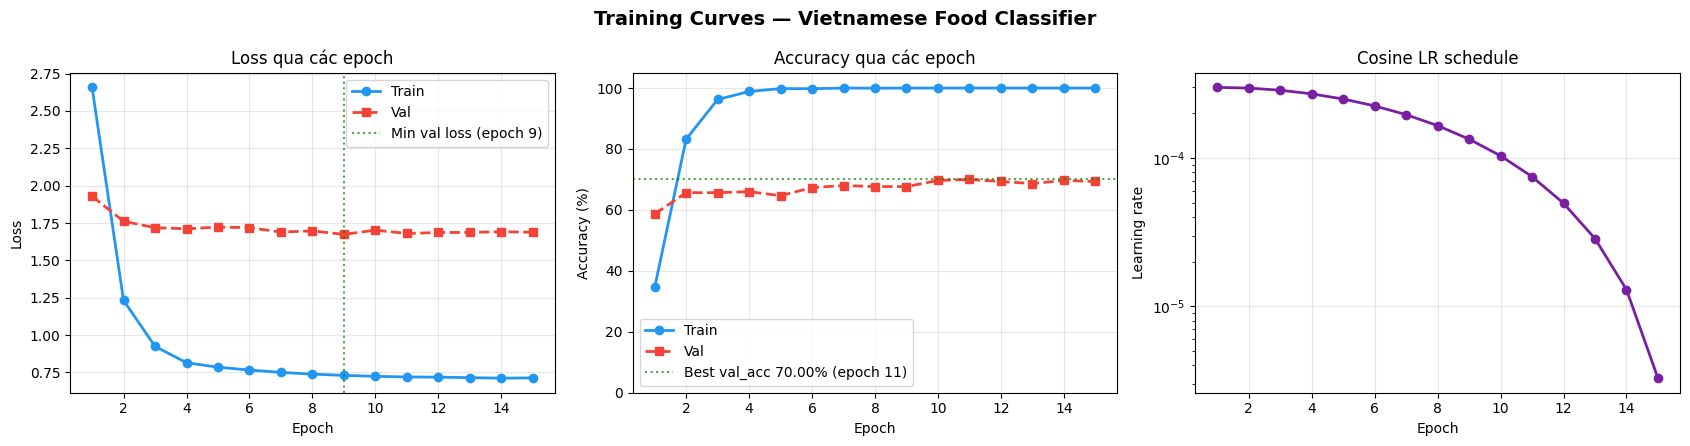

Saved /content/drive/MyDrive/food_classifier/outputs/training_curves.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import json, os

hist_path = os.path.join(PATHS['outputs'], 'history.json')
with open(hist_path) as f:
    history = json.load(f)

epochs = list(range(1, len(history['train_loss']) + 1))

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
fig.suptitle('Training Curves — Vietnamese Food Classifier', fontsize=14, fontweight='bold')

# ── Loss ──
ax = axes[0]
ax.plot(epochs, history['train_loss'], 'o-', color='#2196F3', lw=2, ms=6, label='Train')
ax.plot(epochs, history['val_loss'],   's--', color='#F44336', lw=2, ms=6, label='Val')
best_loss_idx = int(np.argmin(history['val_loss']))
ax.axvline(best_loss_idx + 1, color='green', ls=':', lw=1.5, alpha=0.7,
           label=f'Min val loss (epoch {best_loss_idx+1})')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('Loss qua các epoch')
ax.legend(); ax.grid(alpha=0.3)

# ── Accuracy ──
ax = axes[1]
ax.plot(epochs, [a*100 for a in history['train_acc']], 'o-', color='#2196F3', lw=2, ms=6, label='Train')
ax.plot(epochs, [a*100 for a in history['val_acc']],   's--', color='#F44336', lw=2, ms=6, label='Val')
best_acc = max(history['val_acc']) * 100
best_idx = int(np.argmax(history['val_acc']))
ax.axhline(best_acc, color='green', ls=':', lw=1.5, alpha=0.7,
           label=f'Best val_acc {best_acc:.2f}% (epoch {best_idx+1})')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy (%)')
ax.set_title('Accuracy qua các epoch')
ax.set_ylim(0, 105)
ax.legend(); ax.grid(alpha=0.3)

# ── Learning rate ──
ax = axes[2]
ax.plot(epochs, history['lr'], 'o-', color='#7B1FA2', lw=2, ms=6)
ax.set_xlabel('Epoch'); ax.set_ylabel('Learning rate')
ax.set_title('Cosine LR schedule')
ax.set_yscale('log')
ax.grid(alpha=0.3)

plt.tight_layout()
out_path = os.path.join(PATHS['outputs'], 'training_curves.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved {out_path}")

## 8. Evaluate trên test set

In [ ]:
import torch
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

device = 'cuda' if torch.cuda.is_available() else 'cpu'
ckpt = torch.load(PATHS['best'], map_location=device, weights_only=False)
assert ckpt['class_names'] == CLASS_NAMES, "Class names mismatch giữa checkpoint và recipes.json hiện tại"

model = build_model(NUM_CLASSES, ckpt['cfg']['model_name'], pretrained=False).to(device)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()
print(f"Loaded best model — val_acc={ckpt.get('val_acc'):.4f}, epoch={ckpt.get('epoch')}")

Loaded best model — val_acc=0.7000, epoch=11


In [ ]:
# Predict toàn bộ test set
with open(os.path.join(PATHS['splits'], 'test.json'), 'r', encoding='utf-8') as f:
    test_rows = json.load(f)

test_pairs = [(r['image_path'], r['class']) for r in test_rows]
test_ds = FoodDataset(test_pairs, CLS_TO_IDX, ckpt['cfg']['img_size'], train=False)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=2)

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels, _ in tqdm(test_loader, desc="Evaluating"):
        imgs = imgs.to(device)
        logits = model(imgs)
        all_preds.extend(logits.argmax(1).cpu().numpy().tolist())
        all_labels.extend(labels.numpy().tolist())

print(f"Predicted {len(all_preds)} test samples")

Evaluating:   0%|          | 0/10 [00:00<?, ?it/s]

Predicted 300 test samples


In [ ]:
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                              recall_score, classification_report)

metrics = {
    'accuracy':    round(accuracy_score(all_labels, all_preds) * 100, 2),
    'f1_macro':    round(f1_score(all_labels, all_preds, average='macro') * 100, 2),
    'f1_weighted': round(f1_score(all_labels, all_preds, average='weighted') * 100, 2),
    'precision':   round(precision_score(all_labels, all_preds, average='macro', zero_division=0) * 100, 2),
    'recall':      round(recall_score(all_labels, all_preds, average='macro', zero_division=0) * 100, 2),
    'num_samples': len(all_preds),
}
with open(os.path.join(PATHS['outputs'], 'test_metrics.json'), 'w') as f:
    json.dump(metrics, f, indent=2)

print("=" * 50)
print("TEST METRICS")
print("=" * 50)
for k, v in metrics.items():
    print(f"  {k:15s}: {v}")
print()
print("Per-class report:")
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES, zero_division=0))

TEST METRICS
  accuracy       : 67.33
  f1_macro       : 66.1
  f1_weighted    : 66.1
  precision      : 66.78
  recall         : 67.33
  num_samples    : 300

Per-class report:
                  precision    recall  f1-score   support

        Banh beo       0.58      0.70      0.64        10
    Banh bot loc       0.69      0.90      0.78        10
        Banh can       0.67      0.60      0.63        10
       Banh canh       0.20      0.10      0.13        10
      Banh chung       0.80      0.80      0.80        10
       Banh cuon       0.73      0.80      0.76        10
        Banh duc       0.40      0.20      0.27        10
        Banh gio       0.78      0.70      0.74        10
       Banh khot       0.64      0.70      0.67        10
         Banh mi       0.82      0.90      0.86        10
        Banh pia       0.91      1.00      0.95        10
        Banh tet       0.64      0.90      0.75        10
Banh trang nuong       0.88      0.70      0.78        10
        B

## 9. Plot các độ đo

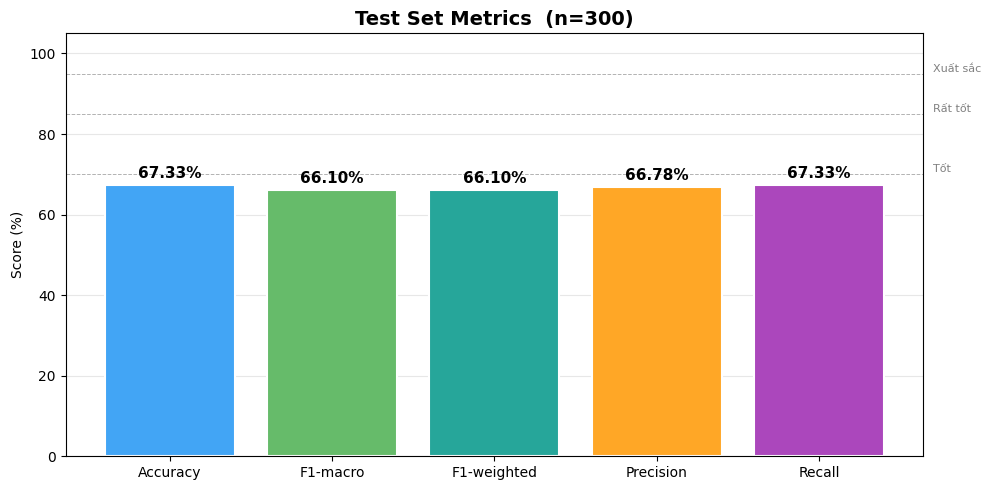

Saved /content/drive/MyDrive/food_classifier/outputs/metrics_bar.png


In [ ]:
# Bar chart cho các metric tổng
fig, ax = plt.subplots(figsize=(10, 5))
metric_names  = ['Accuracy', 'F1-macro', 'F1-weighted', 'Precision', 'Recall']
metric_values = [metrics['accuracy'], metrics['f1_macro'], metrics['f1_weighted'],
                 metrics['precision'], metrics['recall']]
colors = ['#42A5F5', '#66BB6A', '#26A69A', '#FFA726', '#AB47BC']

bars = ax.bar(metric_names, metric_values, color=colors, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, metric_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax.set_ylim(0, 105)
ax.set_ylabel('Score (%)')
ax.set_title(f'Test Set Metrics  (n={metrics["num_samples"]})',
             fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.set_axisbelow(True)

# Threshold lines
for thresh, label in [(70, 'Tốt'), (85, 'Rất tốt'), (95, 'Xuất sắc')]:
    ax.axhline(thresh, color='gray', ls='--', lw=0.7, alpha=0.6)
    ax.text(len(metric_names) - 0.3, thresh + 0.5, label, fontsize=8, color='gray')

plt.tight_layout()
bar_path = os.path.join(PATHS['outputs'], 'metrics_bar.png')
plt.savefig(bar_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved {bar_path}")

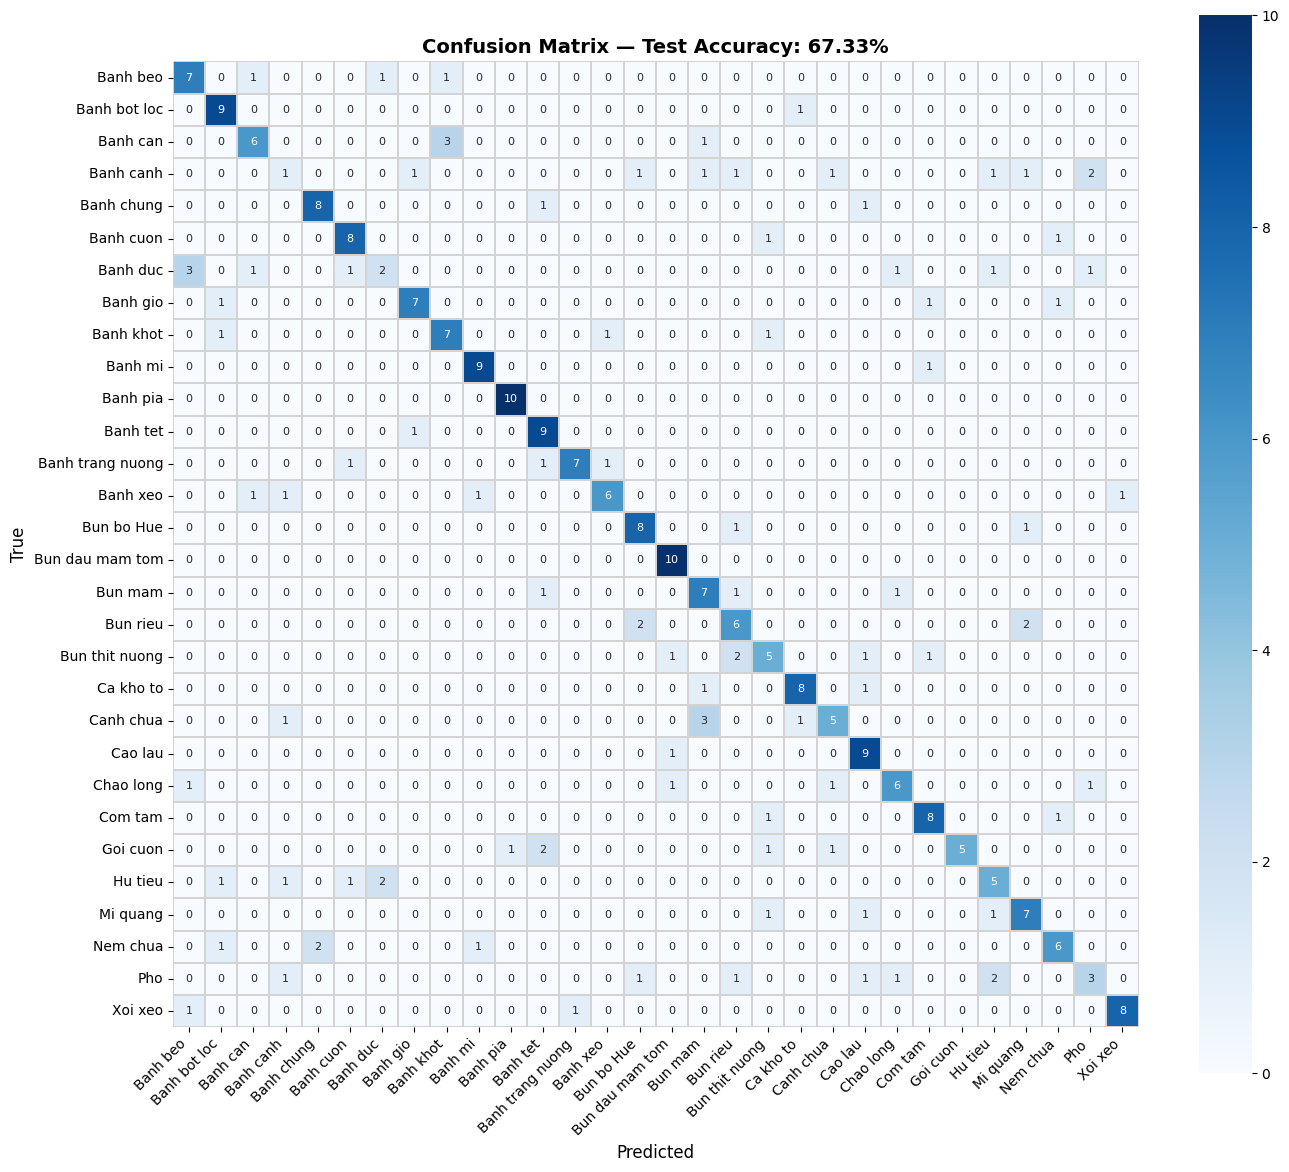

Saved /content/drive/MyDrive/food_classifier/outputs/confusion_matrix.png


In [ ]:
# Confusion matrix
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_preds, labels=list(range(NUM_CLASSES)))

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            cbar=True, ax=ax, square=True, linewidths=0.3, linecolor='lightgray',
            annot_kws={'size': 8})
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('True', fontsize=12)
ax.set_title(f'Confusion Matrix — Test Accuracy: {metrics["accuracy"]}%',
             fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
cm_path = os.path.join(PATHS['outputs'], 'confusion_matrix.png')
plt.savefig(cm_path, dpi=130, bbox_inches='tight')
plt.show()
print(f"Saved {cm_path}")

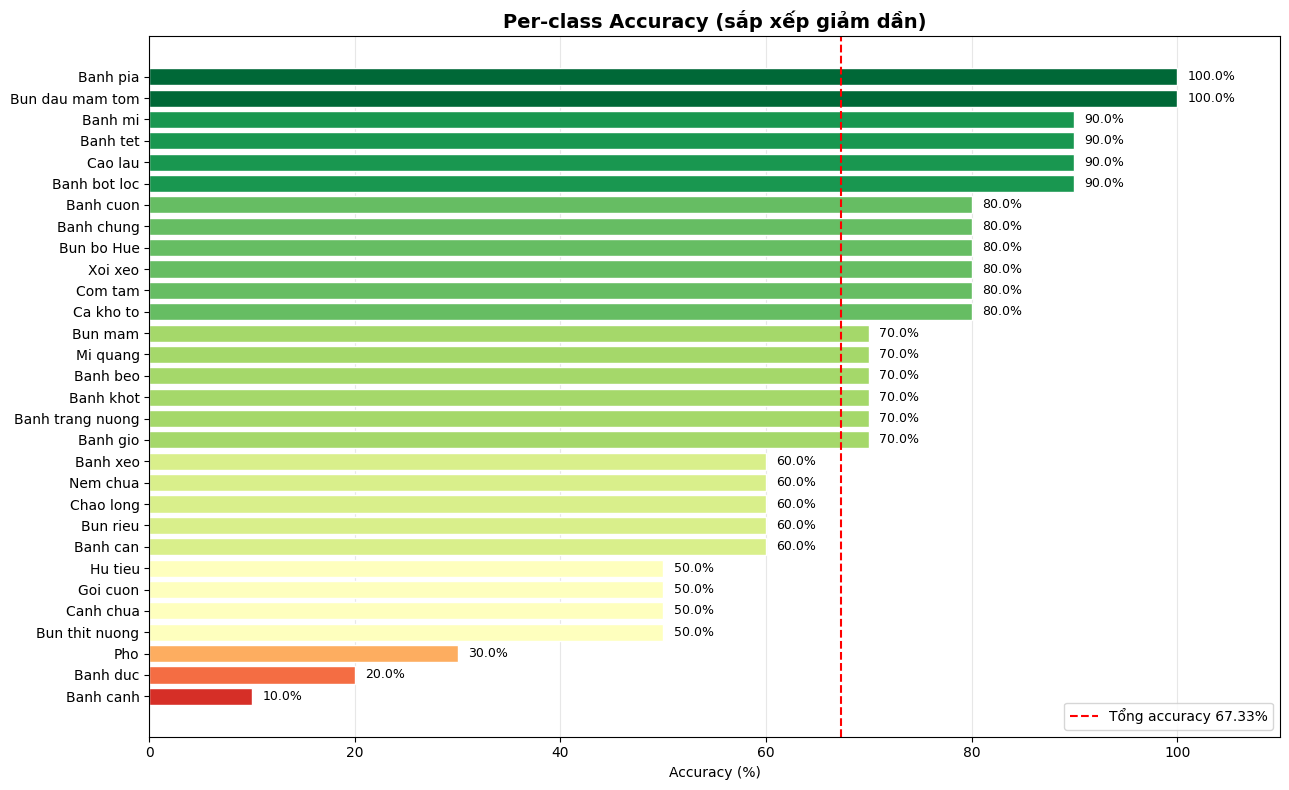

Saved /content/drive/MyDrive/food_classifier/outputs/per_class_accuracy.png


In [ ]:
# Per-class accuracy (xem class nào model làm tốt/kém)
import numpy as np

cm_arr = np.array(cm)
per_class_acc = cm_arr.diagonal() / cm_arr.sum(axis=1).clip(min=1) * 100

# Sort theo accuracy giảm dần
sorted_idx = np.argsort(per_class_acc)[::-1]
sorted_names = [CLASS_NAMES[i] for i in sorted_idx]
sorted_accs  = per_class_acc[sorted_idx]

fig, ax = plt.subplots(figsize=(13, 8))
colors_grad = plt.cm.RdYlGn(sorted_accs / 100)
bars = ax.barh(range(len(sorted_names)), sorted_accs, color=colors_grad, edgecolor='white')
for i, (bar, acc) in enumerate(zip(bars, sorted_accs)):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{acc:.1f}%', va='center', fontsize=9)
ax.set_yticks(range(len(sorted_names)))
ax.set_yticklabels(sorted_names, fontsize=10)
ax.set_xlabel('Accuracy (%)')
ax.set_title('Per-class Accuracy (sắp xếp giảm dần)',
             fontsize=14, fontweight='bold')
ax.set_xlim(0, 110)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
ax.set_axisbelow(True)
ax.axvline(metrics['accuracy'], color='red', ls='--', lw=1.5,
           label=f'Tổng accuracy {metrics["accuracy"]}%')
ax.legend(loc='lower right')

plt.tight_layout()
pc_path = os.path.join(PATHS['outputs'], 'per_class_accuracy.png')
plt.savefig(pc_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved {pc_path}")

## 10. Export model cho Flask deployment

Cell này chuẩn bị 3 file cần thiết để deploy lên Flask:
- `best_model.pt` — model weights
- `class_names.json` — mapping class index <-> tên class
- `recipes.json` — copy sang folder export để gói chung

Tất cả lưu vào `food_classifier/export/` trên Drive — sau đó download về máy.

In [ ]:
import shutil

EXPORT_DIR = PATHS['export']

# 1. Copy model weights
shutil.copy(PATHS['best'], os.path.join(EXPORT_DIR, 'best_model.pt'))

# 2. Class names
with open(os.path.join(EXPORT_DIR, 'class_names.json'), 'w', encoding='utf-8') as f:
    json.dump(CLASS_NAMES, f, ensure_ascii=False, indent=2)

# 3. Copy recipes.json
shutil.copy(PATHS['recipes'], os.path.join(EXPORT_DIR, 'recipes.json'))

# 4. Model card (metadata cho Flask app load)
with open(os.path.join(PATHS['outputs'], 'test_metrics.json')) as f:
    test_metrics = json.load(f)

model_card = {
    'task':         'Vietnamese Food Classification',
    'architecture': ckpt['cfg']['model_name'],
    'num_classes':  NUM_CLASSES,
    'img_size':     ckpt['cfg']['img_size'],
    'imagenet_normalization': True,
    'imagenet_mean': IMAGENET_MEAN,
    'imagenet_std':  IMAGENET_STD,
    'best_val_acc':  ckpt.get('val_acc'),
    'test_metrics':  test_metrics,
}
with open(os.path.join(EXPORT_DIR, 'model_card.json'), 'w', encoding='utf-8') as f:
    json.dump(model_card, f, ensure_ascii=False, indent=2)

print(f"Exported to {EXPORT_DIR}:")
for fn in sorted(os.listdir(EXPORT_DIR)):
    sz = os.path.getsize(os.path.join(EXPORT_DIR, fn))
    if sz > 1024 * 1024:
        print(f"  {fn:25s} {sz/1024/1024:.2f} MB")
    else:
        print(f"  {fn:25s} {sz/1024:.2f} KB")

print("done")

Exported to /content/drive/MyDrive/food_classifier/export:
  best_model.pt             15.72 MB
  class_names.json          0.44 KB
  model_card.json           0.45 KB
  recipes.json              35.42 KB
done


Hãy chọn một tấm ảnh món ăn để hệ thống nhận diện:


Saving banh-xeo-mien-tay_f6e815b3-f8dc-4d8d-ab2e-c1b3600cc85a.jpg to banh-xeo-mien-tay_f6e815b3-f8dc-4d8d-ab2e-c1b3600cc85a.jpg


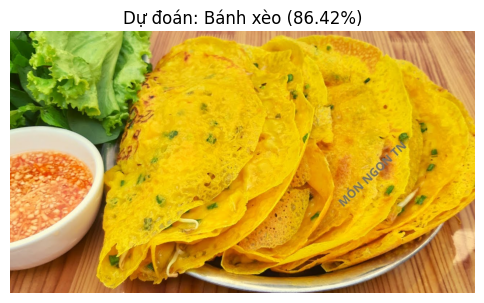

--- THÔNG TIN MÓN ĂN ---
Tên: Bánh xèo
Vùng miền: Miền Trung & Nam
Độ khó: Trung bình
Mô tả: Bánh xèo là bánh chiên giòn từ bột gạo pha nghệ, nhân tôm, thịt, giá đỗ, ăn kèm rau sống cuốn bánh tráng.
Calo: 480 kcal
Thành phần: bột gạo, bột nghệ, nước cốt dừa, tôm tươi, thịt ba chỉ, giá đỗ, hành lá, rau sống (xà lách, cải xanh, húng quế, diếp cá), bánh tráng (tùy chọn), nước mắm chua ngọt

--- CÁCH CHẾ BIẾN ---
Bước 1: Pha bột gạo với nước cốt dừa, bột nghệ, hành lá thái nhỏ.
Bước 2: Làm nóng chảo, phi hành tỏi với tôm và thịt thái mỏng.
Bước 3: Đổ bột láng đều mặt chảo cho mỏng.
Bước 4: Cho giá đỗ vào một nửa bánh, đậy nắp 1 phút.
Bước 5: Mở nắp, gập đôi bánh, chiên thêm cho vỏ giòn vàng.
Bước 6: Cuốn bánh xèo với rau sống, chấm nước mắm chua ngọt.
-------------------------


In [ ]:
import torch
import torch.nn.functional as F
from PIL import Image
import matplotlib.pyplot as plt
from google.colab import files
import json

# 1. Cấu hình thiết bị và load dữ liệu cần thiết
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Load mapping class và recipes
with open(os.path.join(PATHS['export'], 'class_names.json'), 'r') as f:
    class_names = json.load(f)
with open(PATHS['recipes'], 'r', encoding='utf-8') as f:
    recipes_data = json.load(f)

# 2. Build và load lại Model
model = build_model(len(class_names), pretrained=False).to(device)
checkpoint = torch.load(PATHS['best'], map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# 3. Hàm dự đoán
def predict_image(image_path):
    # Tiền xử lý ảnh giống hệt lúc Val/Test
    transform = get_transforms(img_size=224, train=False)

    img = Image.open(image_path).convert('RGB')
    img_tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(img_tensor)
        probs = F.softmax(logits, dim=1)
        conf, pred_idx = torch.max(probs, dim=1)

    cls_name = class_names[pred_idx.item()]
    confidence = conf.item() * 100

    # Lấy thông tin từ recipes.json
    recipe = recipes_data.get(cls_name, {})

    # Hiển thị kết quả
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.title(f"Dự đoán: {recipe.get('name', cls_name)} ({confidence:.2f}%)")
    plt.axis('off')
    plt.show()

    print(f"--- THÔNG TIN MÓN ĂN ---")
    print(f"Tên: {recipe.get('name', 'Không rõ')}")
    print(f"Vùng miền: {recipe.get('region', 'N/A')}")
    print(f"Độ khó: {recipe.get('difficulty', 'N/A')}")
    print(f"Mô tả: {recipe.get('description', '')}")
    print(f"Calo: {recipe.get('nutrition', {}).get('calories', 'N/A')} kcal")
    print(f"Thành phần: {', '.join(recipe.get('ingredients', []))}")

    # --- PHẦN HIỂN THỊ CÁCH NẤU (STEPS) ---
    print("\n--- CÁCH CHẾ BIẾN ---")
    steps = recipe.get('steps', [])
    if steps:
        for i, step in enumerate(steps, 1):
            print(f"Bước {i}: {step}")
    else:
        print("Chưa có thông tin các bước nấu.")

    print("-" * 25)

# 4. Chạy upload ảnh để test
print("Hãy chọn một tấm ảnh món ăn để hệ thống nhận diện:")
uploaded = files.upload()

for fn in uploaded.keys():
    predict_image(fn)

Đã sẵn sàng! Model đạt độ chính xác: 70.00%
Chọn ảnh từ máy tính để nhận diện:


Saving com-tam-5x7.jpg to com-tam-5x7.jpg


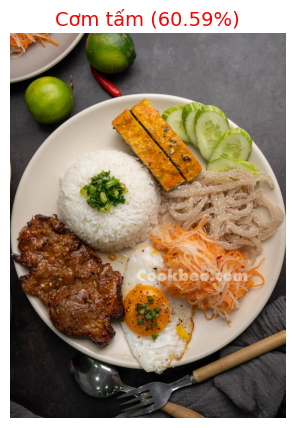


==================== THÔNG TIN MÓN ĂN ====================
Tên món:   Cơm tấm
Vùng miền: Miền Nam
Độ khó:    Dễ
Mô tả:     Cơm tấm là món cơm nấu từ gạo tấm vỡ, thường ăn kèm sườn nướng, bì, chả trứng và nước mắm chua ngọt.
Calo:      650 kcal
Thành phần: gạo tấm, sườn cốt lết, bì heo, trứng, thịt xay, mộc nhĩ, miến, dưa leo, cà chua, đồ chua, nước mắm, tỏi, ớt, đường

*************** CÁCH CHẾ BIẾN ***************
Bước 1: Nấu gạo tấm thành cơm mềm tơi.
Bước 2: Ướp sườn với tỏi, sả, mật ong, nước mắm rồi nướng than đến vàng cháy cạnh.
Bước 3: Trộn bì heo với thính và gia vị.
Bước 4: Hấp chả trứng (thịt xay, trứng, mộc nhĩ, miến).
Bước 5: Pha nước mắm chua ngọt với tỏi ớt.
Bước 6: Bày cơm với sườn, bì, chả, đồ chua, dưa leo, chan nước mắm.



In [ ]:
import torch
import torch.nn.functional as F
from PIL import Image
import matplotlib.pyplot as plt
from google.colab import files
import json
import os

# --- BƯỚC 1: LOAD MODEL & DATA ---
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Load mapping và dữ liệu món ăn
with open(os.path.join(PATHS['export'], 'class_names.json'), 'r') as f:
    class_names = json.load(f)
with open(PATHS['recipes'], 'r', encoding='utf-8') as f:
    recipes_data = json.load(f)

# Khởi tạo lại cấu trúc EfficientNet-B0 và nạp trọng số đã train
model = build_model(len(class_names), pretrained=False).to(device)
checkpoint = torch.load(PATHS['best'], map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Đã sẵn sàng!")

# --- BƯỚC 2: HÀM DỰ ĐOÁN CHI TIẾT ---
def predict_and_show(image_path):
    # Tiền xử lý ảnh (Resize 224, Normalize ImageNet)
    transform = get_transforms(img_size=224, train=False)
    img = Image.open(image_path).convert('RGB')
    img_tensor = transform(img).unsqueeze(0).to(device)

    # Model dự đoán
    with torch.no_grad():
        logits = model(img_tensor)
        probs = F.softmax(logits, dim=1)
        conf, pred_idx = torch.max(probs, dim=1)

    cls_name = class_names[pred_idx.item()]
    confidence = conf.item() * 100
    recipe = recipes_data.get(cls_name, {})

    # Hiển thị ảnh
    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.title(f"{recipe.get('name', cls_name)} ({confidence:.2f}%)", fontsize=14, color='red')
    plt.axis('off')
    plt.show()

    # In thông tin chi tiết ra console
    print(f"\n{'='*20} THÔNG TIN MÓN ĂN {'='*20}")
    print(f"Tên món:   {recipe.get('name', 'N/A')}")
    print(f"Vùng miền: {recipe.get('region', 'N/A')}")
    print(f"Độ khó:    {recipe.get('difficulty', 'N/A')}")
    print(f"Mô tả:     {recipe.get('description', 'N/A')}")
    print(f"Calo:      {recipe.get('nutrition', {}).get('calories', 'N/A')} kcal")
    print(f"Thành phần: {', '.join(recipe.get('ingredients', []))}")

    print(f"\n{'*'*15} CÁCH CHẾ BIẾN {'*'*15}")
    steps = recipe.get('steps', [])
    if steps:
        for i, step in enumerate(steps, 1):
            print(f"Bước {i}: {step}")
    else:
        print("Dữ liệu đang cập nhật bước nấu...")
    print(f"{'='*58}\n")

# --- BƯỚC 3: TEST THỬ ---
print("Chọn ảnh từ máy tính để nhận diện:")
uploaded = files.upload()

for fn in uploaded.keys():
    predict_and_show(fn)